# Train Stochastic Magnet version 2
### Usage
1. Upload files (train.py, tool.py, Dataset.py, Magnetv2.py, MaGNet.py, MAGE.py, F2DAttn.py, S2DAttn.py, Hypergraph.py, my_nas100_2025_data.pt and inference_MC.py) into Google Colab, using the "folder" icon on the left tool bar.
2. Train using T4 GPU
3. Save the .pt files for future reference. Or run the last cell to automatically save all resulting files.



### The output files
| File | Description |
|---|---|
| `best_model_Magnetv1.pth` | Model weights from the epoch with highest validation accuracy. Use this for inference. |
| `final_model_Magnetv1.pth` | Model weights from the last epoch before early stopping. Fallback if best model underperforms. |
| `training_history_Magnetv1.pt` | Dict of per-epoch metrics (loss, accuracy, F1, AUROC, AUPRC) for train/val/test splits. Load with `torch.load()` to compare runs or regenerate plots. |
| `training_history_Magnetv1.png` | Training curves chart (loss, accuracy, precision, recall, F1, AUROC, AUPRC). |
| `mc_results_Magnetv1.pt` | MC Dropout uncertainty results on the test set. Contains `mean_pred` [N×2] (direction probabilities averaged over 100 stochastic forward passes) <br> and `var_pred` [N×2] (variance across those 100 passes — higher = less confident). Use to filter predictions by confidence before trading. |

<br>
<br>
<br>

In [2]:
!pip install torcheval transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 16.0 MB/s eta 0:00:00


In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.2 MB/s eta 0:00:00


In [5]:
!python train.py

Using model: Magnetv2
Using device: cuda
Loading and preprocessing data...
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)
Starting training...

Epoch 1/30
Training: 100% 35/35 [01:12<00:00,  2.06s/it, loss=0.666, accuracy=0.677, precision=0.708, recall=0.94, f1=0.808, auroc=0.458, auprc=0.674]
New best model saved with validation accuracy: 0.5015
Train - Loss: 0.7051, accuracy: 0.4932, precision: 0.5124, recall: 0.5564, f1: 0.5335, auroc: 0.4832, auprc: 0.5081, 
Valid - Loss: 0.7074, accuracy: 0.5015, precision: 0.5376, recall: 0.6014, f1: 0.5677, auroc: 0.4746, auprc: 0.5119, 
Test - Loss: 0.7001, accuracy: 0.4932, precision: 0.5125, recall: 0.5326, f1: 0.5224, auroc: 0.5034, auprc: 0.5343, 

Epoch 2/30
Training: 100% 35/35 [01:08<00:00,  1.97s/it, loss=

In [6]:
!python inference_MC.py

Using model: Magnetv2
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)
Running MC Dropout inference...
  MC run 10/100
  MC run 20/100
  MC run 30/100
  MC run 40/100
  MC run 50/100
  MC run 60/100
  MC run 70/100
  MC run 80/100
  MC run 90/100
  MC run 100/100
mean_pred shape: torch.Size([20460, 2])
var_pred shape: torch.Size([20460, 2])
Figure(800x500)
Mean uncertainty: 0.0011522893328219652
Max uncertainty: 0.0019734082743525505
Saved to mc_results_Magnetv2.pt


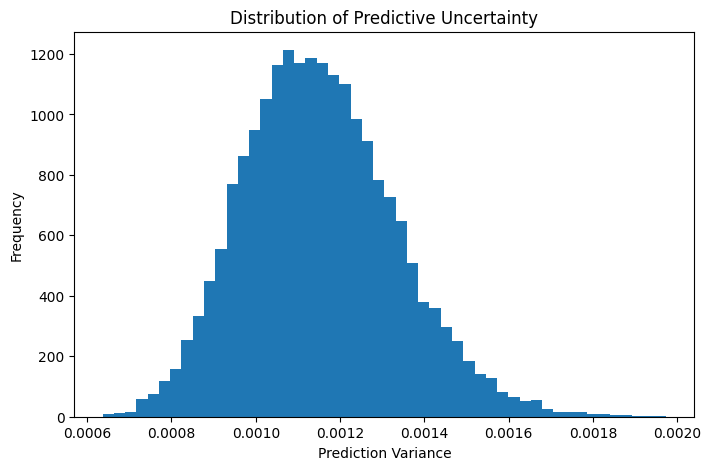

Mean uncertainty: 0.0011522892164066434
Max uncertainty: 0.0019734082743525505


In [7]:
import torch
import matplotlib.pyplot as plt

results = torch.load("mc_results_Magnetv2.pt")
var_pred = results["var_pred"]

uncertainty = var_pred.mean(dim=-1)

plt.figure(figsize=(8, 5))
plt.hist(uncertainty.numpy(), bins=50)
plt.title("Distribution of Predictive Uncertainty")
plt.xlabel("Prediction Variance")
plt.ylabel("Frequency")
plt.savefig("uncertainty_histogram.png", dpi=300)
plt.show()

print("Mean uncertainty:", uncertainty.mean().item())
print("Max uncertainty:", uncertainty.max().item())

In [ ]:
# Save the resulting files (You can also save manually in the left "folder" bar)
from google.colab import files
files.download('best_model_Magnetv1.pth')
files.download('final_model_Magnetv1.pth')
files.download('training_history_Magnetv1.pt')
files.download('training_history_Magnetv1.png')
files.download('mc_results_Magnetv1.pt')
files.download('uncertainty_histogram')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>